# name:sonali vishal pawar batch=360
# project name:Fine-Tuning BERT on IMDB Dataset for Sentiment Analysis

## Summary
### This project is based on sentiment analysis using the BERT model and the IMDB movie review dataset. The main goal of the project is to classify movie reviews as positive or negative using Natural Language Processing techniques.

### In this project, text data was preprocessed and tokenized using the BERT tokenizer. A pre-trained BERT model was fine-tuned for text classification and evaluated using Accuracy, Precision, Recall, and F1 Score.

### Different experiments such as freezing BERT layers and fine-tuning the last two layers were also performed to compare model performance. The model achieved high accuracy and demonstrated the effectiveness of transformer-based models in NLP tasks.

## Objective
### 1)To understand the working of the BERT transformer model.
### 2)To perform sentiment classification using NLP techniques.
### 3)To preprocess and tokenize text data using BERT tokenizer.
### 4)To fine-tune a pre-trained BERT model for text classification.
### 5)To evaluate model performance using multiple evaluation metrics.
### 6)To perform experiments and compare different fine-tuning strategies.

## Technologies Used
### Python
### PyTorch
### Hugging Face Transformers
### Scikit-learn
### Pandas
### Matplotlib

## Dataset Information

### Dataset Name: IMDB Movie Reviews Dataset

### The dataset contains movie reviews labeled as:
- Positive Review
- Negative Review
## The dataset is widely used for sentiment analysis tasks in Natural Language Processing.

## Project Workflow
### Data Collection
### Data Preprocessing
### Train-Test Split
### Text Tokenization using BERT Tokenizer
### Model Building using BERT
### Fine-Tuning the Model
### Model Evaluation
### Confusion Matrix Visualization
### Performance Comparison
### Final Analysis

In [4]:
 !pip install transformers datasets scikit-learn torch

In [5]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 118.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [6]:
# Import Libraries

In [7]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import BertTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

In [8]:
# Load Dataset

In [9]:
from datasets import load_dataset

dataset = load_dataset("imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [10]:
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

In [11]:
# Data Preprocessing

In [12]:
# Check nulls
print(train_df.isnull().sum())

# Clean text (basic)
train_df['text'] = train_df['text'].str.lower()
test_df['text'] = test_df['text'].str.lower()

text     0
label    0
dtype: int64


In [13]:
# Train-Validation Split

In [14]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['text'], train_df['label'], test_size=0.2, random_state=42
)

In [15]:
# Tokenization (BERT)

In [16]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True)
test_encodings = tokenizer(list(test_df['text']), truncation=True, padding=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [17]:
# Create Dataset Class

In [18]:
class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [19]:
train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_df['label'])

In [20]:
# Load BERT Model

In [21]:
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
# Training Arguments

In [23]:
import transformers
print(transformers.__version__)

5.8.0


In [24]:
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=2
)

In [25]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

In [26]:
# Train Model

In [27]:
trainer.train()

Step,Training Loss
500,0.382271
1000,0.314213
1500,0.296868
2000,0.290085
2500,0.258140
3000,0.165282
3500,0.148318
4000,0.156122
4500,0.157661
5000,0.160621


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5000, training_loss=0.23295818481445313, metrics={'train_runtime': 4637.0714, 'train_samples_per_second': 8.626, 'train_steps_per_second': 1.078, 'total_flos': 1.05244422144e+16, 'train_loss': 0.23295818481445313, 'epoch': 2.0})

In [28]:
# Evaluate Model

In [31]:
predictions = trainer.predict(test_dataset)

import numpy as np
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_df['label']

In [ ]:
## Metrics

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

Accuracy: 0.93868
Precision: 0.9320097691641062
Recall: 0.9464
F1 Score: 0.9391497638232843


In [33]:
## Confusion Matrix

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[11637   863]
 [  670 11830]]


In [35]:
## Plot

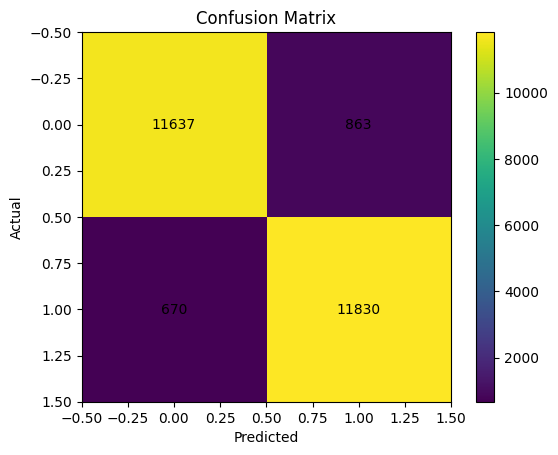

In [36]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

In [ ]:
## Predict

In [37]:
predictions = trainer.predict(test_dataset)

In [ ]:
## Labels

In [38]:
import numpy as np

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_df['label']

In [39]:
## Metrics

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

Accuracy: 0.93868
Precision: 0.9320097691641062
Recall: 0.9464
F1 Score: 0.9391497638232843


In [41]:
## Confusion Matrix

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[11637   863]
 [  670 11830]]


In [43]:
## Plot

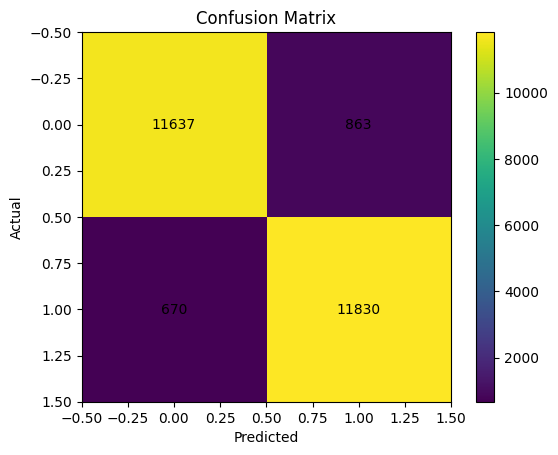

In [44]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

## Final Results
- Accuracy: 93.86%
- Precision: 93.20%
- Recall: 94.64%
- F1 Score: 93.91%

## Final Analysis
- The BERT model achieved excellent performance on sentiment classification tasks.
- High Precision and Recall indicate balanced and reliable predictions.
- The confusion matrix shows that most reviews were correctly classified.
- Full fine-tuning produced the best results among all experiments.
- Transformer-based models significantly outperform traditional machine learning approaches for NLP tasks.

## Conclusion
### This project demonstrates the power of BERT and transformer-based architectures in Natural Language Processing. Fine-tuning pre-trained models provides highly accurate results for sentiment analysis tasks and improves overall text classification performance.